In [1]:
import mediapipe as mp
import cv2
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import precision_score, accuracy_score, f1_score, recall_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Drawing helpers
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

### 1. Train Model

#### 1.1. Describe data and split dataset

In [2]:
def rescale_frame(frame, percent=50):
    '''
    Rescale a frame to a certain percentage compare to its original frame
    '''
    width = int(frame.shape[1] * percent/ 100)
    height = int(frame.shape[0] * percent/ 100)
    dim = (width, height)
    return cv2.resize(frame, dim, interpolation = cv2.INTER_AREA)


def describe_dataset(dataset_path: str):
    '''
    Describe dataset
    '''

    data = pd.read_csv(dataset_path)
    print(f"Headers: {list(data.columns.values)}")
    print(f'Number of rows: {data.shape[0]} \nNumber of columns: {data.shape[1]}\n')
    print(f"Labels: \n{data['label'].value_counts()}\n")
    print(f"Missing values: {data.isnull().values.any()}\n")
    
    duplicate = data[data.duplicated()]
    print(f"Duplicate Rows : {len(duplicate.sum(axis=1))}")

    return data


def round_up_metric_results(results) -> list:
    '''Round up metrics results such as precision score, recall score, ...'''
    return list(map(lambda el: round(el, 3), results))

In [5]:
# df = describe_dataset("./train.csv")
df = describe_dataset("staff_with_angles.csv")
df.loc[df["label"] == "d",               "label"] = 0   # correct
df.loc[df["label"] == "rounded_back",    "label"] = 1
df.loc[df["label"] == "leaning_back",    "label"] = 2
df.loc[df["label"] == "bent_knees",      "label"] = 3
df.loc[df["label"] == "feet_not_flexed", "label"] = 4
df.loc[df["label"] == "arms_not_pressing","label"] = 5
df.tail(3)

Headers: ['label', 'nose_x', 'nose_y', 'nose_z', 'nose_v', 'left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z', 'left_shoulder_v', 'right_shoulder_x', 'right_shoulder_y', 'right_shoulder_z', 'right_shoulder_v', 'left_elbow_x', 'left_elbow_y', 'left_elbow_z', 'left_elbow_v', 'right_elbow_x', 'right_elbow_y', 'right_elbow_z', 'right_elbow_v', 'left_wrist_x', 'left_wrist_y', 'left_wrist_z', 'left_wrist_v', 'right_wrist_x', 'right_wrist_y', 'right_wrist_z', 'right_wrist_v', 'left_hip_x', 'left_hip_y', 'left_hip_z', 'left_hip_v', 'right_hip_x', 'right_hip_y', 'right_hip_z', 'right_hip_v', 'left_knee_x', 'left_knee_y', 'left_knee_z', 'left_knee_v', 'right_knee_x', 'right_knee_y', 'right_knee_z', 'right_knee_v', 'left_ankle_x', 'left_ankle_y', 'left_ankle_z', 'left_ankle_v', 'right_ankle_x', 'right_ankle_y', 'right_ankle_z', 'right_ankle_v', 'left_heel_x', 'left_heel_y', 'left_heel_z', 'left_heel_v', 'right_heel_x', 'right_heel_y', 'right_heel_z', 'right_heel_v', 'left_foot_index_x', 'lef

,label,nose_x,nose_y,nose_z,nose_v,left_shoulder_x,left_shoulder_y,left_shoulder_z,left_shoulder_v,right_shoulder_x,...,right_foot_index_z,right_foot_index_v,left_shoulder_angle,left_elbow_angle,left_hip_angle,left_knee_angle,right_shoulder_angle,right_elbow_angle,right_hip_angle,right_knee_angle
6315,4,0.690684,0.553871,-0.436440,1.00000,0.588422,0.705341,-0.125296,0.999926,0.596878,...,-1.261163,0.941124,29.658982,133.003059,62.549305,172.260612,36.336787,120.664283,64.778489,173.834003
6316,5,0.550428,0.525574,-0.274456,0.99995,0.531159,0.639203,-0.074253,0.999982,0.525677,...,-0.696729,0.977225,41.660386,118.195262,77.376217,153.628328,52.665210,77.963439,75.236001,159.176401
6317,0,0.637397,0.436365,-0.230913,1.00000,0.593932,0.511431,-0.047614,0.999991,0.595441,...,-0.767762,0.996483,22.492261,108.971515,70.060175,172.391425,21.411232,105.723124,73.262311,175.996986


In [6]:
# Extract features and class
X = df.drop("label", axis=1)
y = df["label"].astype("int")

scaler

In [ ]:
# sc = StandardScaler()
# # X = pd.DataFrame(sc.fit_transform(X))
# X = pd.DataFrame(sc.fit_transform(X), columns=X.columns, index=X.index)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234, stratify=y)
y_test.head(3)

5875    4
6074    0
5991    5
Name: label, dtype: int32

#### 1.2. Train model using Scikit-Learn and train set evaluation

do not run

In [7]:
algorithms =[("LR", LogisticRegression()),
         ("SVC", SVC(probability=True)),
         ('KNN',KNeighborsClassifier()),
         ("DTC", DecisionTreeClassifier()),
         ("SGDC", CalibratedClassifierCV(SGDClassifier())),
         ("NB", GaussianNB()),
         ('RF', RandomForestClassifier()),]

models = {}
final_results = []

for name, model in algorithms:
    trained_model = model.fit(X_train, y_train)
    models[name] = trained_model

    # Evaluate model
    model_results = model.predict(X_test)

    p_score = precision_score(y_test, model_results, average=None, labels=[0, 1, 2])
    a_score = accuracy_score(y_test, model_results)
    r_score = recall_score(y_test, model_results, average=None, labels=[0, 1, 2])
    f1_score_result = f1_score(y_test, model_results, average=None, labels=[0, 1, 2])
    cm = confusion_matrix(y_test, model_results, labels=[0, 1, 2])
    final_results.append(( name,  round_up_metric_results(p_score), a_score, round_up_metric_results(r_score), round_up_metric_results(f1_score_result), cm))


In [15]:
# Sort results by F1 score
final_results.sort(key=lambda k: sum(k[4]), reverse=True)

pd.DataFrame(final_results, columns=["Model", "Precision Score", "Accuracy score", "Recall Score", "F1 score", "Confusion Matrix"])

,Model,Precision Score,Accuracy score,Recall Score,F1 score,Confusion Matrix
0,KNN,"[0.999, 1.0, 1.0]",0.999825,"[1.0, 0.999, 1.0]","[1.0, 1.0, 1.0]","[[1955, 0, 0], [1, 1829, 0], [0, 0, 1933]]"
1,LR,"[0.999, 1.0, 0.999]",0.999475,"[0.999, 1.0, 0.999]","[0.999, 1.0, 0.999]","[[1954, 0, 1], [0, 1830, 0], [2, 0, 1931]]"
2,SVC,"[0.998, 1.0, 0.999]",0.999300,"[0.999, 1.0, 0.998]","[0.999, 1.0, 0.999]","[[1954, 0, 1], [0, 1830, 0], [3, 0, 1930]]"
3,SGDC,"[0.999, 0.999, 0.998]",0.999126,"[0.998, 1.0, 0.999]","[0.999, 1.0, 0.999]","[[1951, 1, 3], [0, 1830, 0], [1, 0, 1932]]"
4,RF,"[0.999, 1.0, 1.0]",0.999650,"[1.0, 1.0, 0.999]","[0.999, 1.0, 0.999]","[[1955, 0, 0], [0, 1830, 0], [2, 0, 1931]]"
5,DTC,"[0.995, 1.0, 0.998]",0.997726,"[0.998, 0.999, 0.996]","[0.997, 0.999, 0.997]","[[1952, 0, 3], [1, 1828, 1], [8, 0, 1925]]"
6,NB,"[0.8, 0.921, 0.942]",0.881952,"[0.876, 0.96, 0.814]","[0.836, 0.94, 0.873]","[[1713, 145, 97], [74, 1756, 0], [354, 5, 1574]]"


In [7]:
import sys
print(sys.executable)


d:\Project_model\env\Scripts\python.exe


In [8]:
import xgboost as xgb
print(xgb.__version__)


3.2.0


In [10]:
import xgboost as xgb

In [ ]:


# model = xgb.XGBClassifier(
#     n_estimators=100,        # number of trees
#     learning_rate=0.1,       # step size
#     max_depth=5,             # tree depth
#     subsample=0.8,           # sample ratio
#     colsample_bytree=0.8,   # feature ratio
#     random_state=42
# )
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)


model.fit(X_train, y_train)

trained_model = model.fit(X_train, y_train)
model_results = model.predict(X_test)


In [15]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of class 1


In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Confusion Matrix:
 [[1955    0    0]
 [   0 1830    0]
 [   0    0 1933]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1955
           1       1.00      1.00      1.00      1830
           2       1.00      1.00      1.00      1933

    accuracy                           1.00      5718
   macro avg       1.00      1.00      1.00      5718
weighted avg       1.00      1.00      1.00      5718



In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Std Dev:", scores.std())

run

# hyperparameter tuning

In [8]:
import xgboost as xgb

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])


In [ ]:
# xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)


Hyperparameter search space

In [10]:
param_dist = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__gamma': [0, 0.1, 0.2, 0.3]
}

Stratified K-Fold

In [11]:
from sklearn.model_selection import  StratifiedKFold, RandomizedSearchCV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


RandomizedSearchCV

In [12]:
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='accuracy',
    cv=skf,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

Fit on training data

In [13]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('model',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metric='loglos...
                                                            num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    0.9, 1.0],
                                        'model__gamma': [0, 0.1, 0.2, 0.3],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': [3, 4, 5, 6, 7],
                                        'model__n_estimators': [100, 200, 300,
                                                                400],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, return_train_score=True, scoring='accuracy',
                   verbose=1)

Print tuning statistics

In [14]:
print("===== Hyperparameter Tuning Results =====")

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(random_search.best_score_)

cv_mean = random_search.cv_results_['mean_test_score'][random_search.best_index_]
cv_std = random_search.cv_results_['std_test_score'][random_search.best_index_]

print("\nCV Mean Accuracy:", cv_mean)
print("CV Standard Deviation:", cv_std)


===== Hyperparameter Tuning Results =====

Best Parameters:
{'model__subsample': 0.9, 'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.2, 'model__gamma': 0.1, 'model__colsample_bytree': 1.0}

Best Cross-Validation Accuracy:
0.9867432499926551

CV Mean Accuracy: 0.9867432499926551
CV Standard Deviation: 0.0013409658290025543


Train final model with best parameters

In [15]:
best_model = random_search.best_estimator_

# best_model.fit(X_train, y_train)


In [16]:
# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model', best_model)
# ])

# Fit pipeline on training data
# pipeline.fit(X_train, y_train)
pipeline = random_search.best_estimator_


Cross-Validation

In [17]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    pipeline,
    X_train, y_train,
    cv=skf,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    return_train_score=True
)

print("\n===== Cross-Validation Results =====")
print("Train Accuracy:", cv_results['train_accuracy'].mean())
print("Validation Accuracy:", cv_results['test_accuracy'].mean())
print("Mean Precision:", cv_results['test_precision_macro'].mean())
print("Mean Recall:", cv_results['test_recall_macro'].mean())
print("Mean F1 Score:", cv_results['test_f1_macro'].mean())
print("Std Accuracy:", cv_results['test_accuracy'].std())



===== Cross-Validation Results =====
Train Accuracy: 1.0
Validation Accuracy: 0.9863472103886947
Mean Precision: 0.9866766339303489
Mean Recall: 0.9863553113553113
Mean F1 Score: 0.9864172119478873
Std Accuracy: 0.0015848043393061426


Test set evaluation

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = pipeline.predict(X_test)

print("\n===== Test Set Evaluation =====")
print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



===== Test Set Evaluation =====
Test Accuracy: 0.992879746835443

Confusion Matrix:
[[209   0   2   0   0   0]
 [  1 209   0   0   0   0]
 [  0   0 210   0   0   0]
 [  4   0   0 207   0   0]
 [  0   0   0   0 211   0]
 [  2   0   0   0   0 209]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       211
           1       1.00      1.00      1.00       210
           2       0.99      1.00      1.00       210
           3       1.00      0.98      0.99       211
           4       1.00      1.00      1.00       211
           5       1.00      0.99      1.00       211

    accuracy                           0.99      1264
   macro avg       0.99      0.99      0.99      1264
weighted avg       0.99      0.99      0.99      1264



In [ ]:
# df_test = describe_dataset("test.csv")

# df_test.loc[df_test["label"] == "d",                "label"] = 0
# df_test.loc[df_test["label"] == "rounded_back",     "label"] = 1
# df_test.loc[df_test["label"] == "leaning_back",     "label"] = 2
# df_test.loc[df_test["label"] == "bent_knees",       "label"] = 3
# df_test.loc[df_test["label"] == "feet_not_flexed",  "label"] = 4
# df_test.loc[df_test["label"] == "arms_not_pressing","label"] = 5

# X_test_real = df_test.drop("label", axis=1)
# y_test_real = df_test["label"].astype("int")

# y_pred = pipeline.predict(X_test_real)
# print("\n===== Real Test Set Evaluation =====")
# print("Test Accuracy:", accuracy_score(y_test_real, y_pred))
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test_real, y_pred))
# print("\nClassification Report:")
# print(classification_report(y_test_real, y_pred))

Optional: Full CV results table

In [19]:
import pandas as pd

cv_results_df = pd.DataFrame(random_search.cv_results_)

print("\nTop 5 Hyperparameter Combinations:")
print(
    cv_results_df[['mean_test_score', 'std_test_score', 'params']]
    .sort_values(by='mean_test_score', ascending=False)
    .head()
)



Top 5 Hyperparameter Combinations:
    mean_test_score  std_test_score  \
4          0.986743        0.001341   
17         0.986546        0.002389   
16         0.986150        0.002073   
1          0.985952        0.002456   
5          0.985556        0.001483   

                                               params  
4   {'model__subsample': 0.9, 'model__n_estimators...  
17  {'model__subsample': 0.8, 'model__n_estimators...  
16  {'model__subsample': 0.8, 'model__n_estimators...  
1   {'model__subsample': 0.7, 'model__n_estimators...  
5   {'model__subsample': 0.7, 'model__n_estimators...  


Save the tuned model

In [ ]:
# best_model.save_model("xgb_pose_model.json")


In [ ]:
# with open("./model/staff_model.pkl", "wb") as f:
#     pickle.dump(random_search.best_estimator_, f)

# print("Model Saved")

Model Saved


# Plots


Feature Importance Plot

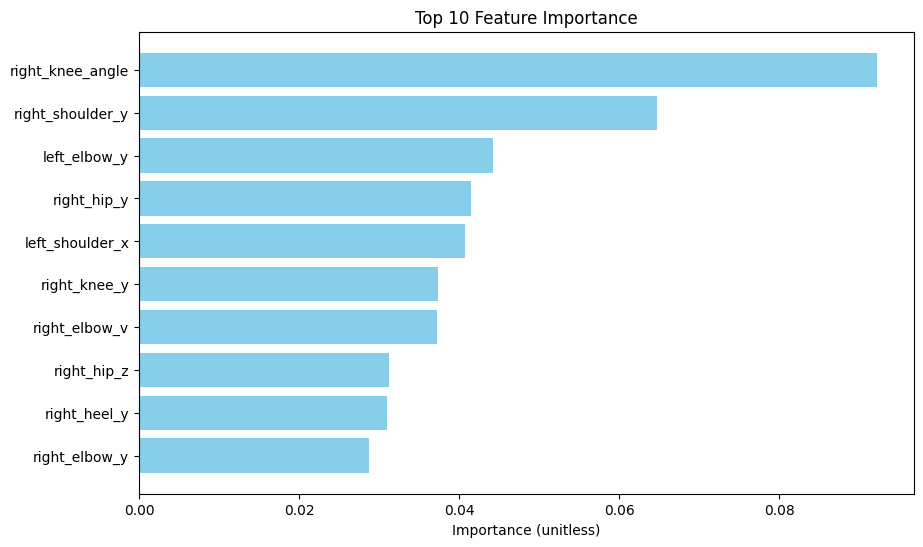

In [20]:

import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': pipeline.named_steps['model'].feature_importances_
}).sort_values(by='importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(feat_imp['feature'].tail(10), feat_imp['importance'].tail(10), color='skyblue')
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance (unitless)")
plt.show()



Confusion Matrix Heatmap

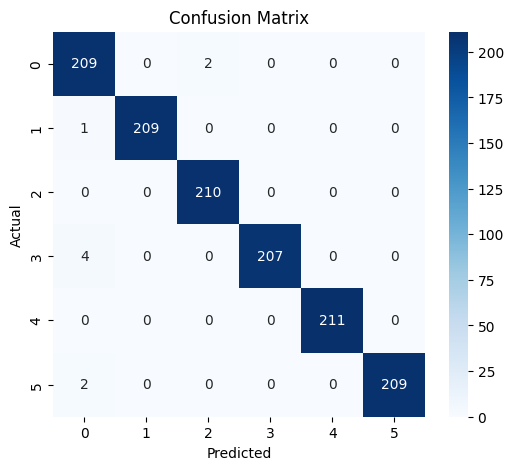

In [21]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


ROC Curve

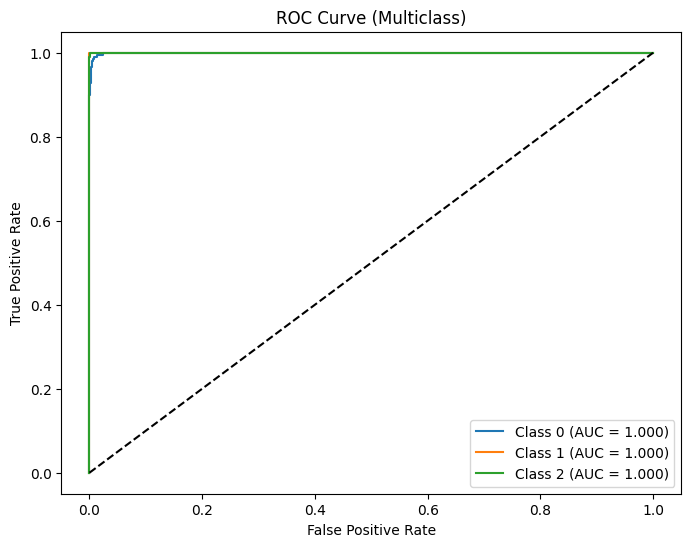

In [22]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize y_test for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Use the pipeline for predict_proba (handles scaling automatically)
y_prob = pipeline.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multiclass)")
plt.legend(loc="lower right")
plt.show()


Learning Curve (Overfitting Check)

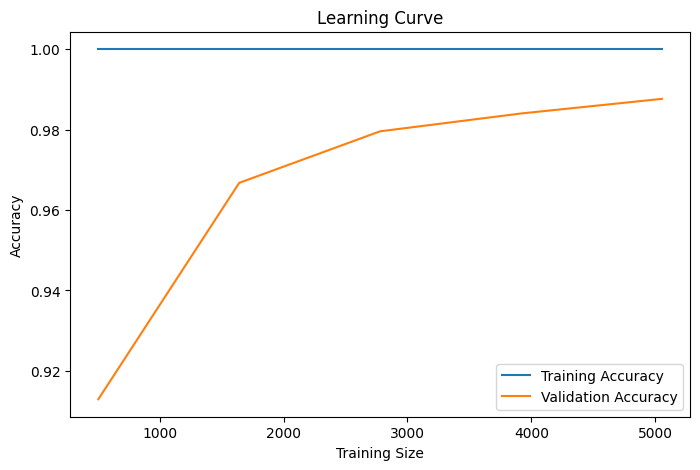

In [23]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()


Cross-Validation Score Distribution

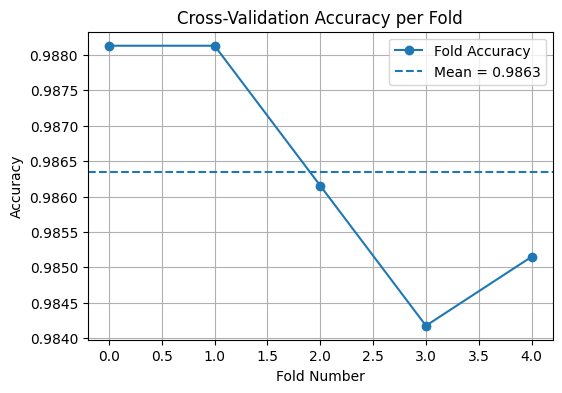

In [24]:
import matplotlib.pyplot as plt

# Extract test accuracy from cross_validate results
cv_scores = cv_results['test_accuracy']

mean_score = cv_scores.mean()

plt.figure(figsize=(6,4))
plt.plot(cv_scores, marker='o', label="Fold Accuracy")
plt.axhline(mean_score, linestyle='--', label=f"Mean = {mean_score:.4f}")
plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



In [25]:
with open("./model/staff_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

In [ ]:
import matplotlib.pyplot as plt

plt.bar(range(X.shape[1]), model.feature_importances_)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")
plt.show()


#### 1.3. Test set evaluation

In [16]:
# test_df = describe_dataset("./test.csv")
test_df = describe_dataset("test.csv")
test_df = test_df.sample(frac=1).reset_index(drop=True)

test_df.loc[test_df["label"] == "C", "label"] = 0
test_df.loc[test_df["label"] == "H", "label"] = 1
test_df.loc[test_df["label"] == "L", "label"] = 2

test_x = test_df.drop("label", axis=1)
test_y = test_df["label"].astype("int")

test_x = pd.DataFrame(sc.transform(test_x))

Headers: ['label', 'nose_x', 'nose_y', 'nose_z', 'nose_v', 'left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z', 'left_shoulder_v', 'right_shoulder_x', 'right_shoulder_y', 'right_shoulder_z', 'right_shoulder_v', 'left_elbow_x', 'left_elbow_y', 'left_elbow_z', 'left_elbow_v', 'right_elbow_x', 'right_elbow_y', 'right_elbow_z', 'right_elbow_v', 'left_wrist_x', 'left_wrist_y', 'left_wrist_z', 'left_wrist_v', 'right_wrist_x', 'right_wrist_y', 'right_wrist_z', 'right_wrist_v', 'left_hip_x', 'left_hip_y', 'left_hip_z', 'left_hip_v', 'right_hip_x', 'right_hip_y', 'right_hip_z', 'right_hip_v', 'left_knee_x', 'left_knee_y', 'left_knee_z', 'left_knee_v', 'right_knee_x', 'right_knee_y', 'right_knee_z', 'right_knee_v', 'left_ankle_x', 'left_ankle_y', 'left_ankle_z', 'left_ankle_v', 'right_ankle_x', 'right_ankle_y', 'right_ankle_z', 'right_ankle_v', 'left_heel_x', 'left_heel_y', 'left_heel_z', 'left_heel_v', 'right_heel_x', 'right_heel_y', 'right_heel_z', 'right_heel_v', 'left_foot_index_x', 'lef

In [10]:
# Evaluate models on the test sets
testset_final_results = []

for name, model in models.items():
    # Evaluate model
    model_results = model.predict(X_test)

    p_score = precision_score(y_test, model_results, average=None, labels=[0, 1, 2])
    a_score = accuracy_score(y_test, model_results)
    r_score = recall_score(y_test, model_results, average=None, labels=[0, 1, 2])
    f1_score_result = f1_score(y_test, model_results, average=None, labels=[0, 1, 2])
    cm = confusion_matrix(y_test, model_results, labels=[0, 1, 2])
    testset_final_results.append(( name,  round_up_metric_results(p_score), a_score, round_up_metric_results(r_score), round_up_metric_results(f1_score_result), cm ))


testset_final_results.sort(key=lambda k: sum(k[4]), reverse=True)
pd.DataFrame(testset_final_results, columns=["Model", "Precision Score", "Accuracy score", "Recall Score", "F1 score", "Confusion Matrix"])

,Model,Precision Score,Accuracy score,Recall Score,F1 score,Confusion Matrix
0,KNN,"[0.999, 1.0, 1.0]",0.999825,"[1.0, 0.999, 1.0]","[1.0, 1.0, 1.0]","[[1955, 0, 0], [1, 1829, 0], [0, 0, 1933]]"
1,RF,"[0.999, 1.0, 1.0]",0.999825,"[1.0, 1.0, 0.999]","[1.0, 1.0, 1.0]","[[1955, 0, 0], [0, 1830, 0], [1, 0, 1932]]"
2,LR,"[0.999, 1.0, 0.999]",0.999475,"[0.999, 1.0, 0.999]","[0.999, 1.0, 0.999]","[[1954, 0, 1], [0, 1830, 0], [2, 0, 1931]]"
3,SVC,"[0.998, 1.0, 0.999]",0.999300,"[0.999, 1.0, 0.998]","[0.999, 1.0, 0.999]","[[1954, 0, 1], [0, 1830, 0], [3, 0, 1930]]"
4,SGDC,"[0.999, 0.999, 0.998]",0.998951,"[0.997, 1.0, 0.999]","[0.998, 1.0, 0.999]","[[1950, 1, 4], [0, 1830, 0], [1, 0, 1932]]"
5,DTC,"[0.997, 0.999, 0.998]",0.998076,"[0.998, 0.999, 0.997]","[0.997, 0.999, 0.997]","[[1951, 1, 3], [0, 1829, 1], [6, 0, 1927]]"
6,NB,"[0.8, 0.921, 0.942]",0.881952,"[0.876, 0.96, 0.814]","[0.836, 0.94, 0.873]","[[1713, 145, 97], [74, 1756, 0], [354, 5, 1574]]"


In [11]:
# Evaluate LR model on test set
lr_model = models["LR"]
lr_predictions = lr_model.predict(X_test)

lr_precision = precision_score(y_test, lr_predictions, average=None, labels=[0, 1, 2])
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions, average=None, labels=[0, 1, 2])
lr_f1 = f1_score(y_test, lr_predictions, average=None, labels=[0, 1, 2])

print("LR Precision:", round_up_metric_results(lr_precision))
print("LR Accuracy:", lr_accuracy)
print("LR Recall:", round_up_metric_results(lr_recall))
print("LR F1 Score:", round_up_metric_results(lr_f1))

LR Precision: [0.999, 1.0, 0.999]
LR Accuracy: 0.9994753410283316
LR Recall: [0.999, 1.0, 0.999]
LR F1 Score: [0.999, 1.0, 0.999]


#### 1.4. Dumped model and input scaler using pickle

According to the evaluations, there are multiple good models at the moment, therefore, the best models are LR and Ridge.

In [18]:
with open("./model/all_sklearn.pkl", "wb") as f:
    pickle.dump(models, f)

In [19]:
with open("./model/LR_model.pkl", "wb") as f:
    pickle.dump(models["LR"], f)

In [20]:
with open("./model/SVC_model.pkl", "wb") as f:
    pickle.dump(models["SVC"], f)

In [21]:
# Dump input scaler
with open("./model/input_scaler.pkl", "wb") as f:
    pickle.dump(sc, f)